## 6.2 랭그래프 활용

### 6.2.1 루프 구현하기

In [13]:
# %%capture --no-stderr
# %pip install -U langgraph
# %pip install -U langchain-openai
# %pip install -U python-dotenv

In [14]:
# from google.colab import drive
# drive.mount('/content/drive')

In [15]:
from dotenv import load_dotenv
import os

# .env 파일에서 환경 변수 로드
load_dotenv("D:\WorkSpace\Python\langchain-tutorial\Ch05. GraphRAG")

False

In [16]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# 실습에서 사용할 그래프의 상태값 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 실습에서 사용할 그래프 정의
graph_builder = StateGraph(State)

In [17]:
from langchain_openai import ChatOpenAI

# 오픈AI 클라이언트 정의
llm = ChatOpenAI(model="gpt-4o-mini")

# 오픈AI를 호출하여 응답을 받아 온 뒤, 상태값에 저장하여 반환하는 챗봇 함수 정의
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# 챗봇 노드 정의
graph_builder.add_node("chatbot", chatbot)

In [18]:
from langgraph.graph import StateGraph, START, END
# 진입지점
graph_builder.add_edge(START, "chatbot")
# 종료지점
graph_builder.add_edge("chatbot", END)

In [19]:
graph = graph_builder.compile()

In [20]:
while True:
    # 사용자의 질의 입력받음
    user_input = input("User: ")
    print("User:", user_input)

    # 사용자가 quit 혹은 exit 혹은 q를 입력했다면 루프 종료
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    # 사용자의 입력을 그래프에 입력하여 정의된 흐름 실행
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


User: q
Goodbye!


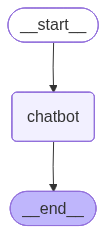

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### 6.2.2 조건문 구현하기

In [22]:
# %%capture --no-stderr
# %pip install -U tavily-python
# %pip install -U langchain_community

In [ ]:
from dotenv import load_dotenv

# .env 파일에서 환경 변수 로드
load_dotenv("D:\WorkSpace\Python\langchain-tutorial\Ch05. GraphRAG")

False

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
# from langchain_tavily import TavilySearch

# Tavily검색 엔진을 도구로 정의
tool = TavilySearchResults(max_results=2, tavily_api_key="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")
tools = [tool]
tool.invoke("내일 대한민국 서울의 날씨는?")

C:\Users\an9383\AppData\Local\Temp\ipykernel_14524\3491263705.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
C:\Users\an9383\AppData\Local\Temp\ipykernel_14524\3491263705.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2, tavily_api_key="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")


[{'title': '서울특별시, 서울시, 대한민국 3일 날씨 예보 | AccuWeather',
  'url': 'https://www.accuweather.com/ko/kr/seoul/226081/weather-forecast/226081',
  'content': 'rain drop 39%  오전 7시   20°\n\nrain drop 47%  오전 8시   21°\n\nrain drop 46%  오전 9시   22°\n\nrain drop 54%  오전 10시   22°\n\nrain drop 40%  오전 11시   23°\n\nrain drop 34%  오후 12시   24°\n\nrain drop 22%  오후 1시   25°\n\nrain drop 0%\n\n## 일별 예보\n\n오늘\n\n5. 28.\n\n28° 15°\n\n오전 중 한두 차례 짧은 소나기; 구름이 줄어들고 습함\n\n \n\n맑음\n\n55% 금\n\n5. 29.\n\n29° 14°\n\n맑음\n\n \n\n맑음\n\n0% 토\n\n5. 30.\n\n29° 15°\n\n맑음\n\n \n\n맑음\n\n0% 일\n\n5. 31.\n\n30° 16°\n\n흐릿함\n\n \n\n약간 흐림\n\n0% 월\n\n6. 1.\n\n31° 16°\n\n약간 흐리고 따뜻함\n\n \n\n약간 흐림\n\n0% 화\n\n6. 2.\n\n31° 18°\n\n맑고 따뜻함\n\n \n\n약간 흐림\n\n1% 수\n\n6. 3.\n\n33° 19°\n\n약간 흐리고 따뜻함\n\n \n\n대체로 흐림\n\n0% 목\n\n6. 4.\n\n30° 18°\n\n대체로 맑고 따뜻함\n\n \n\n약간 흐림\n\n25% 금\n\n6. 5.\n\n27° 17°\n\n맑음\n\n \n\n대체로 맑음\n\n2% 토\n\n6. 6.\n\n28° 17°\n\n맑음\n\n \n\n맑음\n\n1%\n\n## 해와 달\n\n 14 시간 29 분\n\n일출 AM 5:15\n\n일몰 PM 7:44\n\n 10 시간 24 분\n\n일출

In [25]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages


# 그래프 상태 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]


# 그래프 정의
graph_builder = StateGraph(State)

# 오픈AI 클라이언트 정의
llm = ChatOpenAI(model="gpt-4o-mini")
# 오픈AI 클라이언트에 Tavily 검색 엔진 도구를 할당
llm_with_tools = llm.bind_tools(tools)

# 챗봇 함수 정의
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 그래프에 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)

In [26]:
import json

from langchain_core.messages import ToolMessage


# 도구 노드로 사용될 클래스
class BasicToolNode:

    # 도구 노드에서 사용될 초기 파라미터 정의
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    # 도구 노드가 호출되었을때의 행동 정의
    def __call__(self, inputs: dict):
        # 입력된 상태의 가장 마지막 메세지 획득
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        # 메세지의 tool_calls 에 도구호출을 위한 값들이 존재한다면 이를 활용해 도구 호출
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            # 도구 호출의 결과물을 ToolMessage로 정의하여 출력값에 저장
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result, ensure_ascii=False),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        # 출력값을 상태값 형식에 맞춰 반환
        return {"messages": outputs}


# 도구 노드 정의
tool_node = BasicToolNode(tools=[tool])
# 도구 노드 그래프에 추가
graph_builder.add_node("tools", tool_node)

In [27]:
from typing import Literal


# 도구노드 호출 여부를 결정하는 함수 정의
def route_tools(
        state: State,
) -> Literal["tools", "__end__"]:
    # 상태값의 가장 최근 메세지를 정의
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    # 가장 최근 메세지가 tool_calls 속성을 포함하고 있다면 tools 노드를 아니라면 종료지점을 반환
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"


# 챗봇 노드에 조건부 엣지를 정의
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", "__end__": "__end__"},
)

In [28]:
# 도구 노드와 챗봇 노드 연결
graph_builder.add_edge("tools", "chatbot")
# 진입지점으로 챗봇 노드 지정
graph_builder.add_edge(START, "chatbot")

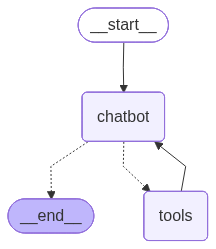

In [29]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### 6.2.3 스트리밍

In [30]:
from langchain_core.messages import BaseMessage

while True:
    # 사용자의 질문을 입력받습니다
    user_input = input("User: ")
    print("User:", user_input)
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    # 업데이트된 내용을 확인할 수 있는 그래프 스트리밍을 정의합니다.
    events = graph.stream(input={"messages": [("user", user_input)]}, stream_mode="updates")

    # 그래프 이벤트 내의 메세지를 출력합니다.
    for event in events:
        for value in event.values():
            if isinstance(value["messages"][-1], BaseMessage):
                print("Assistant:", value["messages"][-1].content)


User: q
Goodbye!


### 6.2.4 상태 저장하기

In [31]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [32]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


tool = TavilySearchResults(max_results=2, tavily_api_key="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")
tools = [tool]

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

# 미리 빌드된 도구노드
tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

# 미리 빌드된 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# 체크포인터를 지정하여 그래프를 컴파일
graph = graph_builder.compile(checkpointer=memory)

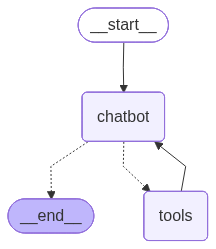

In [33]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
config = {"configurable": {"thread_id": "1"}}

In [35]:
user_input = "안녕! 내 이름은 오해원이야."

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕! 내 이름은 오해원이야.
================================== Ai Message ==================================

안녕하세요, 오해원님! 반갑습니다. 어떻게 도와드릴까요?


In [36]:
user_input = "내 이름을 기억하니?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름을 기억하니?
================================== Ai Message ==================================

네, 오해원님! 당신의 이름을 기억하고 있습니다. 다른 질문이나 요청이 있으시면 언제든지 말씀해 주세요!


In [37]:
events = graph.stream(
    {"messages": [("user", user_input)]},
    {"configurable": {"thread_id": "2"}},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름을 기억하니?
================================== Ai Message ==================================

죄송하지만, 이전 대화 내용을 기억할 수 없어서 당신의 이름을 알 수 없습니다. 하지만 새로운 대화를 시작할 수 있습니다! 당신의 이름이 무엇인가요?


In [38]:
snapshot = graph.get_state(config)
print(snapshot)

StateSnapshot(values={'messages': [HumanMessage(content='안녕! 내 이름은 오해원이야.', additional_kwargs={}, response_metadata={}, id='b532b109-a8d5-43f8-a14e-cebeba7aa876'), AIMessage(content='안녕하세요, 오해원님! 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 90, 'total_tokens': 110, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_31455a11c2', 'id': 'chatcmpl-Dl4Rdj8EBRs1CS0RrsW2RxiKKtdNV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e76e0-4e87-7332-910e-3f99263d7716-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 90, 'output_tokens': 20, 'total_tokens': 110, 'input_token_details': {'audio': 0, 'cache_

### 6.2.5 루프 개입하기

In [39]:
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["tools"],
)

In [40]:
user_input = "지금 서울 날씨 어때?"
config = {"configurable": {"thread_id": "2"}}
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

지금 서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_zJbkyRDw87XC5WINU7Ze8Dlk)
 Call ID: call_zJbkyRDw87XC5WINU7Ze8Dlk
  Args:
    query: 서울 날씨


In [41]:
snapshot = graph.get_state(config)
print(snapshot.next)

('tools',)


In [42]:
from langchain_core.messages import AIMessage

# 최근 메세지
existing_message = snapshot.values["messages"][-1]
# 최근 메세지의 id
existing_message_id = existing_message.tool_calls[0]["id"]

# 강제할 응답 정의
answer = (
    "서울의 날씨는 매우 맑아요."
)

# 강제할 응답을 포함한 메세지 상태 정의
new_messages = [
    ToolMessage(content=answer, tool_call_id=existing_message_id),
    AIMessage(content=answer),
]
# 그래프 상태를 새로 작성한 메세지 상태로 변경
graph.update_state(
    config,
    {"messages": new_messages},
)


{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15bd5a-fd94-60e7-8005-d0b490f37abf'}}

In [43]:
print("\n\nLast 2 messages;")
print(graph.get_state(config).values["messages"][-2:])



Last 2 messages;
[ToolMessage(content='서울의 날씨는 매우 맑아요.', id='02dff094-f9cb-45de-861f-2dc1d13ba806', tool_call_id='call_zJbkyRDw87XC5WINU7Ze8Dlk'), AIMessage(content='서울의 날씨는 매우 맑아요.', additional_kwargs={}, response_metadata={}, id='63a8de09-3a55-4cad-92ce-93ad41a3ba00', tool_calls=[], invalid_tool_calls=[])]


In [44]:
existing_message = snapshot.values["messages"][-3]
print(existing_message)

content='죄송하지만, 이전 대화 내용을 기억할 수 없어서 당신의 이름을 알 수 없습니다. 하지만 새로운 대화를 시작할 수 있습니다! 당신의 이름이 무엇인가요?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 86, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_31455a11c2', 'id': 'chatcmpl-Dl4Rf6FMQleBE2SPRvHAwDHVSSdVL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e76e0-56a8-7480-a1cf-a9b3fc5cd428-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 86, 'output_tokens': 39, 'total_tokens': 125, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [45]:
from langchain_core.messages import AIMessage

user_input = "지금 서울 날씨 어때?"
config = {"configurable": {"thread_id": "3"}}
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

지금 서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_zwodf1Afh2klCV80yBkPE9EW)
 Call ID: call_zwodf1Afh2klCV80yBkPE9EW
  Args:
    query: 서울 날씨


In [46]:
snapshot = graph.get_state(config)
existing_message = snapshot.values["messages"][-1]
new_tool_call = existing_message.tool_calls[0].copy()
new_tool_call["args"]["query"] = "지금 경기도 날씨 어때?"
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    id=existing_message.id,
)

graph.update_state(config, {"messages": [new_message]})

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15bd5b-0646-6de1-8002-63b1d9ca51df'}}

In [47]:
print("\n\nLast 2 messages;")
print(graph.get_state(config).values["messages"][-2:])



Last 2 messages;
[HumanMessage(content='지금 서울 날씨 어때?', additional_kwargs={}, response_metadata={}, id='e6e8e96b-0b5e-432b-97d1-036217837f09'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019e76e0-5e33-7673-876d-b9df830aa90e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '지금 경기도 날씨 어때?'}, 'id': 'call_zwodf1Afh2klCV80yBkPE9EW', 'type': 'tool_call'}], invalid_tool_calls=[])]
